# MLP Model

In [1]:
# test out multiple diff layer types, ex. num of hidden layers

import pandas as pd

X_train = pd.read_csv('/content/X_train_scaled.csv')
X_test = pd.read_csv('/content/X_test_scaled.csv')
Y_train = pd.read_csv('/content/Y_train.csv')
Y_test = pd.read_csv('/content/Y_test.csv')

Y_train['Genre'].unique()

array([4, 6, 2, 5, 3, 1, 0])

In [2]:
" Unoptimized code, used as a reference to see how much "

"we will utilize a FFNN to capture hidden interactions between features."
"fully connected nodes and non-linear activation functions"
"11 X-vars (features/attributes/predictors/dimensions), 1 Y-prediction (genre)"
"there are 7 genres"

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD # stochastic gradient descent


input_dim = 11
hidden_dim_1 = 10
hidden_dim_2 = 10
hidden_dim_3 = 10
output_dim = 7

old_model = Sequential()

# when i use ReLU instead of sigmoid, i get actual classification
# using sigmoid only makes this model fail, especially in confusion matrix later
old_model.add(Dense(hidden_dim_1, input_dim=input_dim, activation='relu'))
old_model.add(Dense(hidden_dim_2, activation='relu'))
old_model.add(Dense(hidden_dim_3, activation='relu'))
old_model.add(Dense(output_dim, activation='softmax')) # as per Jake's Piazza instruction

old_model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
" New model using keras random search hyperparmater optimization and top-K genre accuracy "

"we will utilize a FFNN to capture hidden interactions between features."
"fully connected nodes and non-linear activation functions"
"11 X-vars (features/attributes/predictors/dimensions), 1 Y-prediction (genre)"
"there are 7 genres"

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD # stochastic gradient descent

# creating the model as it's own function to allow for hyperparameter tuning
def main_model(hp):
  input_dim = 11
  # in order to allow keras_tuner to run, I have to leave the parameters defined as a testable range
  hidden_dim_1 = hp.Int('units_1', min_value=10, max_value=100, step=10)
  hidden_dim_2 = hp.Int('units_2', min_value=10, max_value=100, step=10)
  hidden_dim_3 = hp.Int('units_3', min_value=10, max_value=100, step=10)
  output_dim = 7
  learn_rate = hp.Float('learning_rate', min_value=0.001, max_value=0.5, sampling='log')
  k_defined = hp.Int('TopK', min_value=1, max_value=5, step=1)

  model = Sequential()

  # when i use ReLU instead of sigmoid, i get actual classification
  # using sigmoid only makes this model fail, especially in confusion matrix later
  model.add(Dense(hidden_dim_1, input_dim=input_dim, activation='relu'))
  model.add(Dense(hidden_dim_2, activation='relu'))
  model.add(Dense(hidden_dim_3, activation='relu'))
  model.add(Dense(output_dim, activation='softmax')) # as per Jake's Piazza instruction

  # implementing top-3 genre matching based on:
  # https://medium.com/@juanfraleonhardt/music-genre-classification-a-machine-learning-exercise-9c83108fd2bb
  sparse_topK_categorical_accuracy = keras.metrics.SparseTopKCategoricalAccuracy(k = k_defined)

  model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=learn_rate), metrics=[sparse_topK_categorical_accuracy])

  return model

In [4]:
# use keras Random Search tuner
# based on https://keras.io/keras_tuner/

# pip install keras-tuner --upgrade
import keras_tuner

tuner = keras_tuner.RandomSearch(
    main_model,
    objective='val_loss',
    max_trials=20,
    overwrite=True)

tuner.search(X_train, Y_train, epochs=20, validation_data=(X_test, Y_test))
best_model = tuner.get_best_models()[0]


Trial 20 Complete [00h 00m 16s]
val_loss: 1.2515829801559448

Best val_loss So Far: 1.2372326850891113
Total elapsed time: 00h 05m 38s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# print out the actual ideal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f'hidden_dim_1 = {best_hps.get("units_1")}')
print(f'hidden_dim_2 = {best_hps.get("units_2")}')
print(f'hidden_dim_3 = {best_hps.get("units_3")}')
print(f'learning_rate = {best_hps.get("learning_rate")}')
print(f'chosen K = {best_hps.get("TopK")}')

hidden_dim_1 = 90
hidden_dim_2 = 80
hidden_dim_3 = 40
learning_rate = 0.06425071266324729
chosen K = 3


In [6]:
# its own cell because it takes so long to run
old_fitted_model = old_model.fit(X_train, Y_train, epochs=50, validation_data=(X_test, Y_test)) #batch_size=128,

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5818 - val_loss: 1.4863
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4170 - val_loss: 1.3825
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3457 - val_loss: 1.4239
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3292 - val_loss: 1.3776
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3080 - val_loss: 1.3949
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2994 - val_loss: 1.3464
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2926 - val_loss: 1.3438
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2841 - val_loss: 1.3965
Epoch 9/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2749 - val_loss: 1.3485
Epoch 10/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2741 - val_loss: 1.3675
Epoch 11/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2753 - val_loss: 1.3761
Epoch 12/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [7]:
# its own cell because it takes so long to run
best_fitted_model = best_model.fit(X_train, Y_train, epochs=50, validation_data=(X_test, Y_test)) #batch_size=128,

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0689 - sparse_top_k_categorical_accuracy: 0.8997 - val_loss: 1.2722 - val_sparse_top_k_categorical_accuracy: 0.8555
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0649 - sparse_top_k_categorical_accuracy: 0.9002 - val_loss: 1.2743 - val_sparse_top_k_categorical_accuracy: 0.8526
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0591 - sparse_top_k_categorical_accuracy: 0.9038 - val_loss: 1.2596 - val_sparse_top_k_categorical_accuracy: 0.8649
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0509 - sparse_top_k_categorical_accuracy: 0.9035 - val_loss: 1.2566 - val_sparse_top_k_categorical_accuracy: 0.8620
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0461 - sparse_top_k_categorical_accuracy: 0.9062 - val_loss: 1.2631 - val_sparse_top_k_categorical_accuracy: 0.8649
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0369 - sparse_top_k_categorical_accuracy: 0.9073

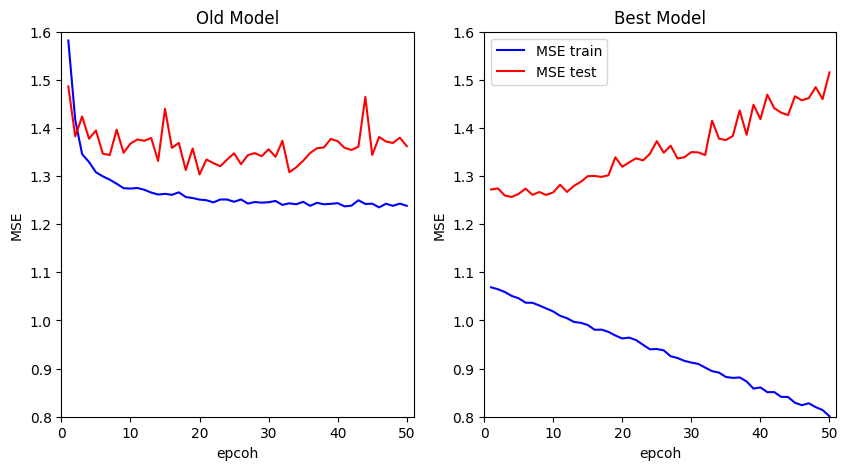

In [14]:
# graph showing reduced mse vs epoch

import matplotlib.pyplot as plt
import numpy as np
fig,(ax1,ax2) = plt.subplots(1,2, figsize=(10,5))#, sharex=True, sharey=True)

epoch = np.arange(1, 51)

old_train_mse = old_fitted_model.history['loss']
old_val_mse = old_fitted_model.history['val_loss']
ax1.plot(epoch, old_train_mse, 'b-', label='MSE train')
ax1.plot(epoch, old_val_mse, 'r-', label='MSE test')
ax1.set_xlabel('epcoh')
ax1.set_ylabel('MSE')
ax1.set_ylim(0.8, 1.6)
ax1.set_xlim(0, 51)
ax1.set_title('Old Model')

best_train_mse = best_fitted_model.history['loss']
best_val_mse = best_fitted_model.history['val_loss']
ax2.plot(epoch, best_train_mse, 'b-', label='MSE train')
ax2.plot(epoch, best_val_mse, 'r-', label='MSE test')
ax2.set_xlabel('epcoh')
ax2.set_ylabel('MSE')
ax2.set_ylim(0.8, 1.6)
ax2.set_xlim(0, 51)
ax2.set_title('Best Model')


# plt.xlabel('Epoch')
# plt.ylabel('MSE')
plt.legend()
plt.show()


In [9]:
# # based on https://www.tensorflow.org/api_docs/python/tf/math/confusion_matrix
# import tensorflow as tf
# import numpy as np

# Y_pred = old_model.predict(X_test)
# labels = np.argmax(Y_test, axis=1)
# predictions = np.argmax(Y_pred, axis=1)

# confusion_matrix = tf.math.confusion_matrix(
#     labels,
#     predictions,
#     num_classes=7,
#     # weights=None,
#     # dtype=tf.dtypes.int32,
#     # name=None
# )

# print(confusion_matrix)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


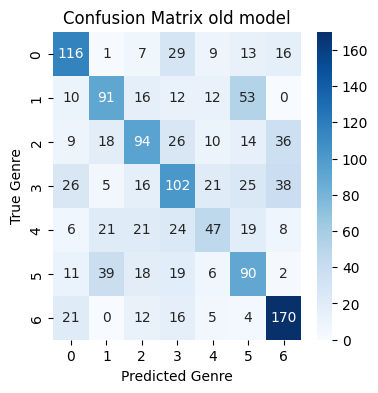

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


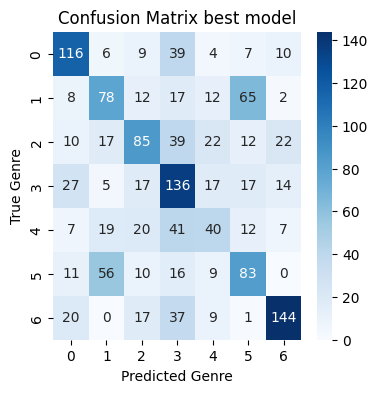

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def print_cm(model_name, name):

  Y_pred = model_name.predict(X_test)
  labels = np.argmax(Y_test, axis=1)
  predictions = np.argmax(Y_pred, axis=1)

  # accuracy = accuracy_score(Y_test, predictions)
  # precision = precision_score(Y_test, predictions, average='macro')
  # recall = recall_score(Y_test, predictions, average='macro')
  # f1 = f1_score(Y_test, predictions, average='macro')

  # print("Accuracy:", accuracy)
  # print("Precision:", precision)
  # print("Recall:", recall)
  # print("F1:", f1)

  old_cm = confusion_matrix(Y_test, predictions)

  plt.figure(figsize=(4, 4))

  sns.heatmap(
      old_cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      # xticklabels=genre_labels,
      # yticklabels=genre_labels
  )

  plt.title(f"Confusion Matrix {name}")
  plt.xlabel("Predicted Genre")
  plt.ylabel("True Genre")

  plt.show()

print_cm(old_model, 'old model')
print_cm(best_model, 'best model')